In [22]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

In [25]:
# Load Sentinel road-indices and keep 2020 only
S2_PARQUET_DIR = "/Users/miranda/Documents/GitHub/Sentinel-FYP/data/ghana_parquet"

s2 = pd.read_parquet(S2_PARQUET_DIR)
s2 = s2.copy()
s2["osm_id"] = s2["osm_id"].astype(str)

s2_2020 = s2[s2["year"] == 2020].copy()

idx_cols = ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]
for c in idx_cols:
    s2_2020[c] = pd.to_numeric(s2_2020[c], errors="coerce")

# Drop rows where all indices are missing
s2_2020 = s2_2020.dropna(subset=idx_cols, how="all").copy()

print("2020 rows:", len(s2_2020))
print("2020 unique osm_id:", s2_2020["osm_id"].nunique())
s2_2020.head(3)

2020 rows: 2387160
2020 unique osm_id: 326546


,osm_id,fclass,quarter,NDVI,NDMI,NDBI,NDWI,BSI,year
0,520162721,trunk,Q1,0.157278,-0.142099,0.142099,-0.269918,0.183079,2020
1,574240962,trunk,Q1,0.089044,-0.130132,0.130132,-0.173877,0.156009,2020
2,574240965,trunk,Q1,0.058767,-0.161057,0.161057,-0.144965,0.174362,2020


## Descriptive Layer-1 analysis (2020)
Below we compare index distributions by paved vs unpaved and summarize class-level means/std.


In [ ]:
# Summary stats by label
summary = df_road.groupby('layer1_label')[idx_cols].agg(['mean', 'std', 'median']).round(4)
summary


In [ ]:
# Boxplots by index (paved vs unpaved)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, c in zip(axes, idx_cols):
    sns.boxplot(data=df_road, x='layer1_label', y=c, ax=ax)
    ax.set_title(c)
    ax.set_xlabel('')
plt.suptitle('Layer-1 (2020): Index distributions by surface label')
plt.tight_layout()
plt.show()

In [ ]:
# Quarterly means by label (2020)
q_order = ['Q1', 'Q2', 'Q3', 'Q4']
q_stats = (
    df_q.groupby(['quarter', 'layer1_label'])[idx_cols]
    .mean()
    .reset_index()
)
q_stats['quarter'] = pd.Categorical(q_stats['quarter'], categories=q_order, ordered=True)
q_stats = q_stats.sort_values('quarter')

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharex=True)
for ax, c in zip(axes, idx_cols):
    sns.lineplot(data=q_stats, x='quarter', y=c, hue='layer1_label', marker='o', ax=ax)
    ax.set_title(c)
    ax.set_xlabel('')
plt.suptitle('Layer-1 (2020): Quarterly index means (paved vs unpaved)')
plt.tight_layout()
plt.show()

## Baseline predictive check (Layer 1)
This is not your final model yet. It is a baseline test: can 2020 spectral indices separate paved vs unpaved roads?


In [26]:
# Build a larger paved/unpaved label table from Ghana OSM PBF (add-on, does not replace previous section)
from pathlib import Path
import numpy as np
import pandas as pd

try:
    from pyrosm import OSM
except Exception as e:
    raise ImportError("pyrosm is required for this section. Install with: pip install pyrosm") from e

PBF_PATH = Path('/Users/miranda/Documents/GitHub/Sentinel-FYP/data/ghana-260304.osm.pbf')
if not PBF_PATH.exists():
    raise FileNotFoundError(f"PBF not found: {PBF_PATH}")

osm = OSM(str(PBF_PATH))
roads_osm = osm.get_network(network_type='driving')

# Normalize OSM id keys to match Sentinel table
roads_osm = roads_osm.copy()
roads_osm['osm_id'] = roads_osm['id'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()
roads_osm['surface_clean'] = roads_osm['surface'].astype(str).str.lower().str.strip()

focus_classes = ['residential', 'service', 'trunk', 'primary', 'secondary', 'tertiary', 'unclassified']
roads_osm = roads_osm[roads_osm['highway'].isin(focus_classes)].copy()

# Same paved/unpaved mapping used in analysis2020_2023.ipynb
paved_vals = {
    'paved', 'asphalt', 'concrete', 'paving_stones', 'concrete:plates', 'sett',
    'cobblestone', 'metal', 'bricks', 'cement', 'chipseal'
}
unpaved_vals = {
    'unpaved', 'ground', 'dirt', 'earth', 'gravel', 'fine_gravel', 'sand',
    'mud', 'grass', 'compacted', 'pebblestone', 'soil'
}

roads_osm['layer1_label_large'] = np.where(
    roads_osm['surface_clean'].isin(paved_vals), 'paved',
    np.where(roads_osm['surface_clean'].isin(unpaved_vals), 'unpaved', None)
)

label_df_large = roads_osm[['osm_id', 'highway', 'layer1_label_large']].copy()
label_df_large = label_df_large[label_df_large['layer1_label_large'].isin(['paved', 'unpaved'])]
label_df_large = label_df_large.rename(columns={'highway': 'fclass'})

# One row per OSM id for merge stability
label_df_large = label_df_large.drop_duplicates(subset=['osm_id'])

print('Large label rows:', len(label_df_large))
print('Large label unique osm_id:', label_df_large['osm_id'].nunique())
print('Large label balance (%):')
print(label_df_large['layer1_label_large'].value_counts(normalize=True).mul(100).round(2))


Large label rows: 29738
Large label unique osm_id: 29738
Large label balance (%):
layer1_label_large
unpaved    57.17
paved      42.83
Name: proportion, dtype: float64


In [27]:
# Merge larger labels with existing S2-2020 table, then aggregate to one row per road
# Assumes s2_2020 already exists from earlier cells in this notebook.

if 's2_2020' not in globals():
    raise NameError('s2_2020 not found. Run the earlier S2 loading cells first.')

s2_tmp = s2_2020.copy()
s2_tmp['osm_id'] = s2_tmp['osm_id'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

df_q_large = s2_tmp.merge(label_df_large[['osm_id', 'layer1_label_large']], on='osm_id', how='inner')

print('Quarterly merged rows (large labels):', len(df_q_large))
print('Quarterly unique roads (large labels):', df_q_large['osm_id'].nunique())

road_feats_large = (
    df_q_large.groupby(['osm_id', 'layer1_label_large'], as_index=False)
    .agg(
        NDVI_mean=('NDVI', 'mean'), NDVI_std=('NDVI', 'std'),
        NDMI_mean=('NDMI', 'mean'), NDMI_std=('NDMI', 'std'),
        NDBI_mean=('NDBI', 'mean'), NDBI_std=('NDBI', 'std'),
        NDWI_mean=('NDWI', 'mean'), NDWI_std=('NDWI', 'std'),
        BSI_mean=('BSI', 'mean'),  BSI_std=('BSI', 'std')
    )
)

feat_cols_large = [
    'NDVI_mean','NDVI_std','NDMI_mean','NDMI_std','NDBI_mean',
    'NDBI_std','NDWI_mean','NDWI_std','BSI_mean','BSI_std'
]
road_feats_large[feat_cols_large] = road_feats_large[feat_cols_large].fillna(0)

print('Road-level rows (large labels):', len(road_feats_large))
road_feats_large.head(3)


Quarterly merged rows (large labels): 210194
Quarterly unique roads (large labels): 29123
Road-level rows (large labels): 29123


,osm_id,layer1_label_large,NDVI_mean,NDVI_std,NDMI_mean,NDMI_std,NDBI_mean,NDBI_std,NDWI_mean,NDWI_std,BSI_mean,BSI_std
0,1000593771,unpaved,0.488968,0.134820,0.005682,0.077260,-0.005682,0.077260,-0.475683,0.110715,0.022806,0.063707
1,1000593772,unpaved,0.473726,0.124106,-0.009305,0.075062,0.009305,0.075062,-0.444655,0.093835,0.028146,0.063028
2,1000593776,unpaved,0.483420,0.113489,-0.003973,0.068111,0.003973,0.068111,-0.469460,0.094625,0.031302,0.055517


Large-label Layer-1 report:
              precision    recall  f1-score   support

       paved      0.752     0.728     0.740      2468
     unpaved      0.805     0.823     0.814      3357

    accuracy                          0.783      5825
   macro avg      0.778     0.776     0.777      5825
weighted avg      0.782     0.783     0.782      5825



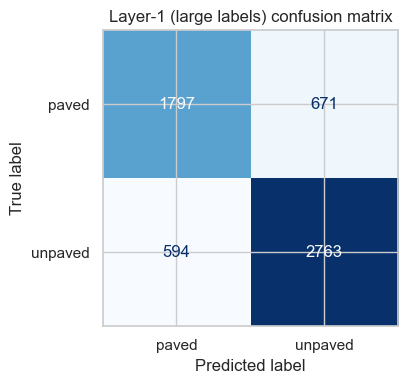

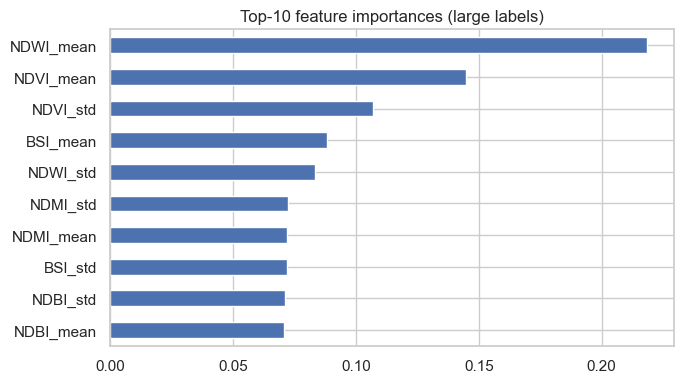

In [28]:
# Layer-1 baseline model on larger labels (RandomForest)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_large = road_feats_large[[
    'NDVI_mean','NDVI_std','NDMI_mean','NDMI_std','NDBI_mean',
    'NDBI_std','NDWI_mean','NDWI_std','BSI_mean','BSI_std'
]].copy()
y_large = road_feats_large['layer1_label_large'].copy()

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_large, y_large, test_size=0.2, random_state=42, stratify=y_large
)

rf_large = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample'
)
rf_large.fit(X_train_l, y_train_l)
pred_l = rf_large.predict(X_test_l)

print('Large-label Layer-1 report:')
print(classification_report(y_test_l, pred_l, digits=3))

cm_l = confusion_matrix(y_test_l, pred_l, labels=['paved', 'unpaved'])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_l, display_labels=['paved', 'unpaved']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Layer-1 (large labels) confusion matrix')
plt.tight_layout()
plt.show()

imp_l = pd.Series(rf_large.feature_importances_, index=X_large.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
imp_l.head(10).sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top-10 feature importances (large labels)')
plt.tight_layout()
plt.show()


### Note

This is an **add-on experiment** using a broader OSM-derived paved/unpaved label inventory. Compare these metrics directly against the earlier Layer‑1 section to report whether larger labels improve robustness.



## Next step after this notebook
If this Layer-1 baseline is stable, next we can:
1. Expand from 2020 to 2020-2023 with robust cloud handling.
2. Add urban/rural and road-class controls.
3. Move to Layer-2 condition labels (IRI / manual validation sample).


In [ ]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

In [ ]:
def find_repo_root(start: Path | None = None, repo_name: str = "Sentinel-FYP") -> Path:
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if p.name == repo_name:
            return p
    raise FileNotFoundError(
        f"Could not find repo root named '{repo_name}' from {start}. "
        "Run this notebook from somewhere inside the repo."
    )

ROOT = find_repo_root()
DATA_DIR = ROOT / "data"

print("Repo root:", ROOT)
print("Data dir:", DATA_DIR)

# Main Sentinel parquet directory
S2_PARQUET_DIR = DATA_DIR / "ghana_parquet"

# Optional local PBF for larger OSM label experiment
PBF_PATH = DATA_DIR / "ghana-260304.osm.pbf"

print("Sentinel parquet exists:", S2_PARQUET_DIR.exists())
print("PBF exists:", PBF_PATH.exists())